# Project Overview: Telco Customer Churn
---

**Group Alpha:**
- Amira Aqila Afdhal
- Christian
- Ditya Ayu Anjani

---

# Problem Understanding
---

## Problem Statement
1. Can we predict whether a customer will churn based on data set?
1. How can we improve the product to keep our customers loyal?
1. Check if we can minimize the cost by removing certain products

## Stakeholder
1. Customer Retention Team: Uses churn prediction to create targeted retention strategies.
1. Marketing Team: Designs promotional campaigns based on churn risk profiles.
1. Product/Service Managers: Adjusts pricing and features to align with customer expectations.

## Goals
1. Predict Churn: Build a machine learning model to accurately classify customers likely to churn.
1. Identify Churn Drivers: Understand which features (e.g., contract type, internet service, payment method) most influence churn.
1. Customer Segmentation: Group customers based on similar usage patterns and risk levels.
1. Optimize Retention Efforts: Enable targeted campaigns with data-driven interventions.

## Metric Evaluation
Target variable:

`1` = Customer `churns` (discontinues subscription)

`0` = Customer `stays`

**Confusion Matrix**
|                             | Prediction: Customer churns (1) | Prediksi: Customer stays (0) |
|-----------------------------|---------------------|----------------------------|
| **Actual: Customer churns (1)**       | True Positive (TP)  | False Negative (FN)        |
| **Actual: Customer stays (0)** | False Positive (FP) | True Negative (TN)         |


- **True Positive (TP)**: Customer actually churns and the model correctly predicts churn
- **False Positive (FP)**: Customer does not churn, but the model predicts churn → might trigger unnecessary retention efforts.
- **False Negative (FN)**: Customer actually churns, but the model predicts no churn → risk of unexpected revenue loss.
- **True Negative (TN)**: Customer does not churn and the model correctly predicts no churn.

### Main focus: Minimize False Negatives (FN)
Since missing actual churners can lead to revenue loss and lower retention rate

Key metrics:

- **Recall**: Measures how many churners are correctly identified by the model.\
Recall = $ \frac{TP}{TP + FN} $

- **ROC AUC (Receiver Operating Characteristic - Area Under Curve)**: Evaluates the model's ability to distinguish churn vs no churn.
- **Balanced Accuracy**: Suitable when dealing with imbalanced datasets (as churners usually form a minority).

---

# Import Libraries
---

In [11]:
# Save Model
import pickle
import os

# Data & Array
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Feature Engineering
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Model Selection & Training
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint

# Optional: to suppress warnings
import warnings

warnings.filterwarnings("ignore")

# Optional: Pandas display option
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", None)

---

# Data Understanding
Data source: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

---

## Read Data Set

In [15]:
# Base
base = pd.read_csv("dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")
base

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [16]:
# Status
status = pd.read_csv("dataset/Tambahan/Telco_customer_churn_status.csv", sep=";")
status = status[
    ["Customer ID", "Satisfaction Score", "Churn Score", "CLTV", "Churn Reason"]
]
status

,Customer ID,Satisfaction Score,Churn Score,CLTV,Churn Reason
0,8779-QRDMV,3,91,5433,Competitor offered more data
1,7495-OOKFY,3,69,5302,Competitor made better offer
2,1658-BYGOY,2,81,3179,Competitor made better offer
3,4598-XLKNJ,2,88,5337,Limited range of services
4,4846-WHAFZ,2,67,2793,Extra data charges
...,...,...,...,...,...
7038,2569-WGERO,5,45,5306,NaN
7039,6840-RESVB,3,59,2140,NaN
7040,2234-XADUH,4,71,5560,NaN
7041,4801-JZAZL,4,59,2793,NaN


In [17]:
# Population
population = pd.read_csv(
    "dataset/Tambahan/Telco_customer_churn_population.csv", sep=";"
)
population = population[["Zip Code", "Population"]]
population

,Zip Code,Population
0,90001,54.492
1,90002,44.586
2,90003,58.198
3,90004,67.852
4,90005,43.019
...,...,...
1666,96145,4.002
1667,96146,942.000
1668,96148,678.000
1669,96150,33.038


In [18]:
# Location
location = pd.read_csv("dataset/Tambahan/Telco_customer_churn_location.csv", sep=";")
location = location[["Customer ID", "City", "Zip Code"]]
location

,Customer ID,City,Zip Code
0,8779-QRDMV,Los Angeles,90022
1,7495-OOKFY,Los Angeles,90063
2,1658-BYGOY,Los Angeles,90065
3,4598-XLKNJ,Inglewood,90303
4,4846-WHAFZ,Whittier,90602
...,...,...,...
7038,2569-WGERO,Landers,92285
7039,6840-RESVB,Adelanto,92301
7040,2234-XADUH,Amboy,92304
7041,4801-JZAZL,Angelus Oaks,92305


In [19]:
# Demographics
demographic = pd.read_csv(
    "dataset/Tambahan/Telco_customer_churn_demographics.csv", sep=";"
)
demographic = demographic[["Customer ID", "Under 30", "Number of Dependents"]]
demographic

,Customer ID,Under 30,Number of Dependents
0,8779-QRDMV,No,0
1,7495-OOKFY,No,1
2,1658-BYGOY,No,3
3,4598-XLKNJ,No,1
4,4846-WHAFZ,No,1
...,...,...,...
7038,2569-WGERO,No,0
7039,6840-RESVB,No,2
7040,2234-XADUH,No,2
7041,4801-JZAZL,No,2


In [20]:
loca_popu = location.merge(population, on="Zip Code", how="left")
loca_popu = loca_popu[["Customer ID", "City", "Population"]]
loca_popu

,Customer ID,City,Population
0,8779-QRDMV,Los Angeles,68.701
1,7495-OOKFY,Los Angeles,55.668
2,1658-BYGOY,Los Angeles,47.534
3,4598-XLKNJ,Inglewood,27.778
4,4846-WHAFZ,Whittier,26.265
...,...,...,...
7038,2569-WGERO,Landers,2.182
7039,6840-RESVB,Adelanto,18.980
7040,2234-XADUH,Amboy,42.000
7041,4801-JZAZL,Angelus Oaks,301.000


In [21]:
# Join all table
df = (
    base.merge(status, left_on="customerID", right_on="Customer ID", how="left")
    .merge(loca_popu, left_on="customerID", right_on="Customer ID", how="left")
    .merge(demographic, left_on="customerID", right_on="Customer ID", how="left")
)

df = df[
    [
        "customerID",
        "gender",
        "Under 30",
        "SeniorCitizen",
        "Partner",
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "Contract",
        "PaperlessBilling",
        "PaymentMethod",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "City",
        "Population",
        "Number of Dependents",
        "CLTV",
        "Satisfaction Score",
        "Churn Score",
        "Churn Reason",
        "Churn",
    ]
]

df

,customerID,gender,Under 30,SeniorCitizen,Partner,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,tenure,MonthlyCharges,TotalCharges,City,Population,Number of Dependents,CLTV,Satisfaction Score,Churn Score,Churn Reason,Churn
0,7590-VHVEG,Female,No,0,Yes,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,1,29.85,29.85,Los Angeles,54.492,0,3964,3,27,NaN,No
1,5575-GNVDE,Male,No,0,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,34,56.95,1889.5,Los Angeles,44.586,0,3441,3,61,NaN,No
2,3668-QPYBK,Male,No,0,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,2,53.85,108.15,Los Angeles,58.198,0,3239,1,86,Competitor made better offer,Yes
3,7795-CFOCW,Male,No,0,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),45,42.30,1840.75,Los Angeles,67.852,0,4307,3,66,NaN,No
4,9237-HQITU,Female,Yes,0,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,2,70.70,151.65,Los Angeles,43.019,2,2701,2,67,Moved,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,No,0,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,24,84.80,1990.5,Adelanto,18.980,2,2140,3,59,NaN,No
7039,2234-XADUH,Female,No,0,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),72,103.20,7362.9,Amboy,42.000,2,5560,4,71,NaN,No
7040,4801-JZAZL,Female,No,0,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,11,29.60,346.45,Angelus Oaks,301.000,2,2793,4,59,NaN,No
7041,8361-LTMKD,Male,No,1,Yes,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,4,74.40,306.6,Fallbrook,42.239,0,5839,2,77,Competitor made better offer,Yes


### Feature Information

| **Feature**            | **Description**                                                                      |
| ---------------------- | ------------------------------------------------------------------------------------ |
| `customerID`           | Unique identifier for each customer                                                  |
| `gender`               | Gender of the customer (e.g., Male or Female)                                        |
| `Under 30`             | Whether the customer is under 30 years old (Yes or No)                               |
| `SeniorCitizen`        | Indicates if the customer is a senior citizen (1 = Yes, 0 = No)                      |
| `Partner`              | Whether the customer has a partner (Yes or No)                                       |
| `PhoneService`         | Whether the customer has phone service (Yes or No)                                   |
| `MultipleLines`        | Whether the customer has multiple phone lines (Yes, No, or No phone service)         |
| `InternetService`      | Type of internet service (DSL, Fiber optic, or No)                                   |
| `OnlineSecurity`       | Whether the customer has online security add-on (Yes, No, or No internet service)    |
| `OnlineBackup`         | Whether the customer has online backup add-on (Yes, No, or No internet service)      |
| `DeviceProtection`     | Whether the customer has device protection add-on (Yes, No, or No internet service)  |
| `TechSupport`          | Whether the customer has tech support add-on (Yes, No, or No internet service)       |
| `StreamingTV`          | Whether the customer uses streaming TV service (Yes, No, or No internet service)     |
| `StreamingMovies`      | Whether the customer uses streaming movies service (Yes, No, or No internet service) |
| `Contract`             | Type of contract (Month-to-month, One year, Two year)                                |
| `PaperlessBilling`     | Whether the customer uses paperless billing (Yes or No)                              |
| `PaymentMethod`        | Payment method used by the customer (e.g., Electronic check, Mailed check)           |
| `tenure`               | Number of months the customer has stayed with the company                            |
| `MonthlyCharges`       | Monthly amount charged to the customer                                               |
| `TotalCharges`         | Total amount charged to the customer over the entire tenure                          |
| `City`                 | City where the customer resides                                                      |
| `Population`           | Population size of the city the customer resides in                                  |
| `Number of Dependents` | Number of dependents associated with the customer                                    |
| `CLTV`                 | Customer Lifetime Value prediction                                                   |
| `Satisfaction Score`   | Satisfaction rating of the customer (e.g., 1 to 5 scale)                             |
| `Churn Score`          | Churn risk score for the customer                                                    |
| `Churn Reason`         | The reason the customer provided for leaving the service                             |
| `Churn`                | Whether the customer churned (Yes or No)                                             |


### Feature Grouping

#### Customer Profile

| **Feature**            | **Description**                                                 |
| ---------------------- | --------------------------------------------------------------- |
| `customerID`           | Unique identifier for each customer                             |
| `gender`               | Gender of the customer (e.g., Male or Female)                   |
| `Under 30`             | Whether the customer is under 30 years old (Yes or No)          |
| `SeniorCitizen`        | Indicates if the customer is a senior citizen (1 = Yes, 0 = No) |
| `Partner`              | Whether the customer has a partner (Yes or No)                  |
| `Number of Dependents` | Number of dependents associated with the customer               |

#### Service Subscription

| **Feature**        | **Description**                                                                      |
| ------------------ | ------------------------------------------------------------------------------------ |
| `PhoneService`     | Whether the customer has phone service (Yes or No)                                   |
| `MultipleLines`    | Whether the customer has multiple phone lines (Yes, No, or No phone service)         |
| `InternetService`  | Type of internet service (DSL, Fiber optic, or No)                                   |
| `OnlineSecurity`   | Whether the customer has online security add-on (Yes, No, or No internet service)    |
| `OnlineBackup`     | Whether the customer has online backup add-on (Yes, No, or No internet service)      |
| `DeviceProtection` | Whether the customer has device protection add-on (Yes, No, or No internet service)  |
| `TechSupport`      | Whether the customer has tech support add-on (Yes, No, or No internet service)       |
| `StreamingTV`      | Whether the customer uses streaming TV service (Yes, No, or No internet service)     |
| `StreamingMovies`  | Whether the customer uses streaming movies service (Yes, No, or No internet service) |

#### Account & Billing

| **Feature**        | **Description**                                                            |
| ------------------ | -------------------------------------------------------------------------- |
| `Contract`         | Type of contract (Month-to-month, One year, Two year)                      |
| `PaperlessBilling` | Whether the customer uses paperless billing (Yes or No)                    |
| `PaymentMethod`    | Payment method used by the customer (e.g., Electronic check, Mailed check) |
| `MonthlyCharges`   | Monthly amount charged to the customer                                     |
| `TotalCharges`     | Total amount charged to the customer over the entire tenure                |
| `tenure`           | Number of months the customer has stayed with the company                  |

#### Location & Demographics

| **Feature**  | **Description**                                     |
| ------------ | --------------------------------------------------- |
| `City`       | City where the customer resides                     |
| `Population` | Population size of the city the customer resides in |

#### Customer Value & Satisfaction

| **Feature**          | **Description**                                          |
| -------------------- | -------------------------------------------------------- |
| `CLTV`               | Customer Lifetime Value prediction                       |
| `Satisfaction Score` | Satisfaction rating of the customer (e.g., 1 to 5 scale) |
| `Churn Score`        | Churn risk score for the customer                        |

#### Churn Outcome

| **Feature**    | **Description**                                          |
| -------------- | -------------------------------------------------------- |
| `Churn`        | Whether the customer churned (Yes or No)                 |
| `Churn Reason` | The reason the customer provided for leaving the service |

---

## Data Profiling

In [32]:
# Data description
df_unique = pd.DataFrame(
    {
        "Features": df.columns.values,
        "Data Type": df.dtypes.values,
        "Data Count": df.count().values,
        "Null Value Count": df.isnull().sum().values,
        "Number of Unique Value": df.nunique().values,
        "Unique Value": [df[col].unique() for col in df.columns],
    }
)


print("Unique Table:")
display(df_unique)

# dataframe information
print(f"Total Rows           :", df.shape[0])
print(f"Total Columns        :", df.shape[1])

print("-----------------------------\nData Types Count     :")
print(df.dtypes.value_counts())

Unique Table:


,Features,Data Type,Data Count,Null Value Count,Number of Unique Value,Unique Value
0,customerID,object,7043,0,7043,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOCW, 9237-HQITU, 9305-CDSKC, 1452-KIOVK, 6713-OKOMC, 7892-POOKP, 6388-TABGU, 9763-GRSKD, 7469-LKBCI, 8091-TTVAX, 0280-XJGEX, 5129-JLPIS, 3655-SNQYZ, 8191-XWSZG, 9959-WOFKT, 4190-MFLUW, 4183-MYFRB, 8779-QRDMV, 1680-VDCWW, 1066-JKSGK, 3638-WEABW, 6322-HRPFA, 6865-JZNKO, 6467-CHFZW, 8665-UTDHZ, 5248-YGIJN, 8773-HHUOZ, 3841-NFECX, 4929-XIHVW, 6827-IEAUQ, 7310-EGVHZ, 3413-BMNZE, 6234-RAAPL, 6047-YHPVI, 6572-ADKRS, 5380-WJKOV, 8168-UQWWF, 8865-TNMNX, 9489-DEDVP, 9867-JCZSP, 4671-VJLCL, 4080-IIARD, 3714-NTNFO, 5948-UJZLF, 7760-OYPDY, 7639-LIAYI, 2954-PIBKO, 8012-SOUDQ, 9420-LOJKX, 6575-SUVOI, 7495-OOKFY, 4667-QONEA, 1658-BYGOY, 8769-KKTPH, 5067-XJQFU, 3957-SQXML, 5954-BDFSG, 0434-CSFON, 1215-FIGMP, 0526-SXDJP, 0557-ASKVU, 5698-BQJOH, 5122-CYFXA, 8627-ZYGSZ, 3410-YOQBQ, 3170-NMYVV, 7410-OIEDU, 2273-QCKXA, 0731-EBJQB, 1891-QRQSA, 8028-PNXHQ, 5630-AHZIL, 2673-CXQEU, 6416-JNVRK, 5590-ZSKRV, 0191-ZHSKZ, 3887-PBQAO, 5919-TMRGD, 8108-UXRQN, 9191-MYQKX, 9919-YLNNG, 0318-ZOPWS, 4445-ZJNMU, 4808-YNLEU, 1862-QRWPE, 2796-NNUFI, 3016-KSVCP, 4767-HZZHQ, 2424-WVHPL, 7233-PAHHL, 6067-NGCEU, 9848-JQJTX, 8637-XJIVR, 9803-FTJCG, 0278-YXOOG, 3212-KXOCR, 4598-XLKNJ, ...]"
1,gender,object,7043,0,2,"[Female, Male]"
2,Under 30,object,7043,0,2,"[No, Yes]"
3,SeniorCitizen,int64,7043,0,2,"[0, 1]"
4,Partner,object,7043,0,2,"[Yes, No]"
5,PhoneService,object,7043,0,2,"[No, Yes]"
6,MultipleLines,object,7043,0,3,"[No phone service, No, Yes]"
7,InternetService,object,7043,0,3,"[DSL, Fiber optic, No]"
8,OnlineSecurity,object,7043,0,3,"[No, Yes, No internet service]"
9,OnlineBackup,object,7043,0,3,"[Yes, No, No internet service]"


Total Rows           : 7043
Total Columns        : 28
-----------------------------
Data Types Count     :
object     20
int64       6
float64     2
Name: count, dtype: int64


<div class="alert alert-info" role="alert">Since `TotalCharges` represents money, it should be of float type</div>

In [34]:
# Check invalid value
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,Population,Number of Dependents,CLTV,Satisfaction Score,Churn Score
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,91.790031,0.468692,4400.295755,3.244924,58.505040
std,0.368612,24.559481,30.090047,183.378434,0.962802,1183.057152,1.201657,21.170031
min,0.000000,0.000000,18.250000,1.004000,0.000000,2003.000000,1.000000,5.000000
25%,0.000000,9.000000,35.500000,11.213000,0.000000,3469.000000,3.000000,40.000000
50%,0.000000,29.000000,70.350000,29.636000,0.000000,4527.000000,3.000000,61.000000
75%,0.000000,55.000000,89.850000,53.204000,0.000000,5380.500000,4.000000,75.500000
max,1.000000,72.000000,118.750000,986.000000,9.000000,6500.000000,5.000000,96.000000


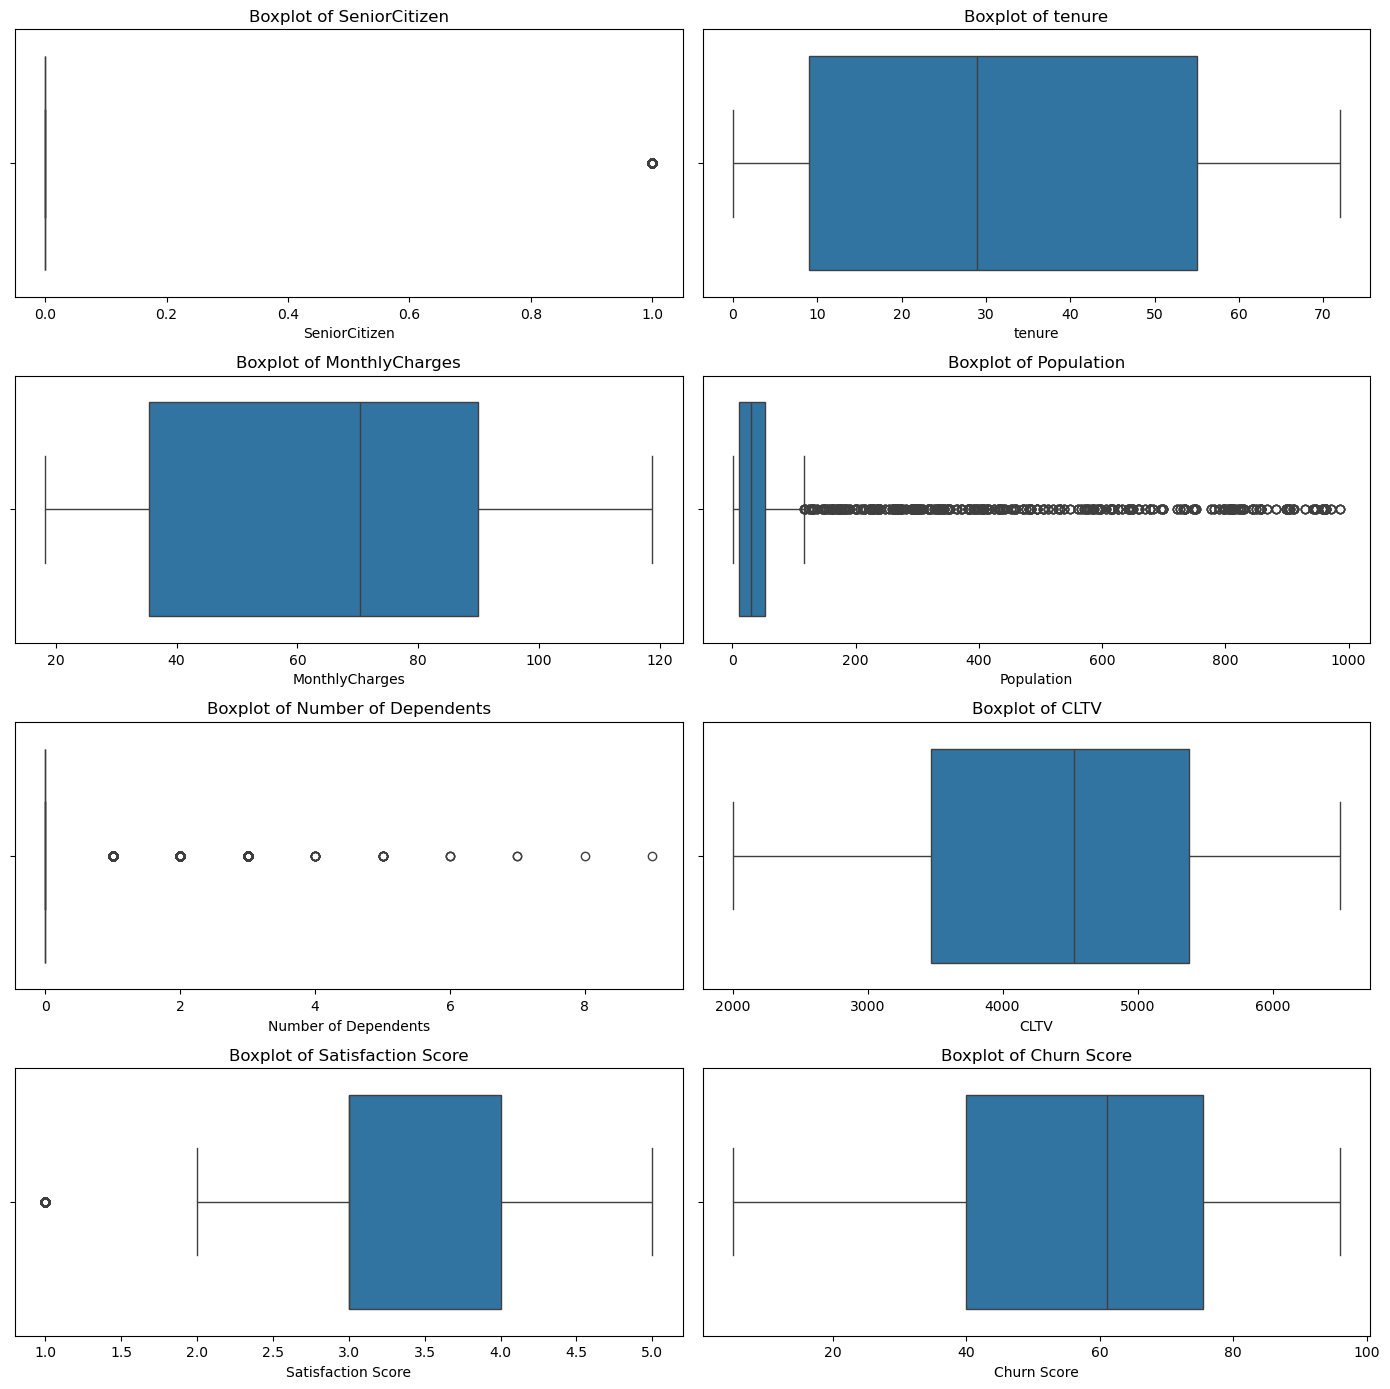

In [35]:
numeric_columns = df.select_dtypes(include=["float64", "int64"]).columns.tolist()

# Visualization
plt.figure(figsize=(14, 14))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
plt.show()

**Result:**
1. `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, `Churn` Change No to False and Yes to True
1. `SeniorCitizen` Change 0 to False and 1 to True
1. `TotalCharges` handle invalid value " "
1. `Churn Reason` change missing value to N/A
1. `tenure`, `MonthlyCharges`, `TotalCharges` change data type to float
1. `MultipleLines` No phone Service change to N/A
1. `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` No internet service change to N/A

---

# Preprocessing
---

## Data Cleansing

### Handle Missing Values

In [41]:
# Check how many row effected by missing values
pd.DataFrame(round(df.isna().sum() / len(df) * 100, 2).astype(str) + "%").rename(
    columns={0: "Missing Value"}
)

,Missing Value
customerID,0.0%
gender,0.0%
Under 30,0.0%
SeniorCitizen,0.0%
Partner,0.0%
PhoneService,0.0%
MultipleLines,0.0%
InternetService,0.0%
OnlineSecurity,0.0%
OnlineBackup,0.0%


<div class="alert alert-success">73.46% of the churn data indicates that the person has not actually churned; other than that, there are no missing values</div>

In [43]:
# Fill missing with N/A
df['Churn Reason'] = df['Churn Reason'].fillna('N/A')

### Handle Invalid Values

In [45]:
# Check how many row effected by invalid values
pd.DataFrame(
    round(
        df[df["TotalCharges"] == " "][["TotalCharges"]].count() / len(df) * 100, 2
    ).astype(str)
    + "%"
).rename(columns={0: "Invalid Value"})

,Invalid Value
TotalCharges,0.16%


<div class="alert alert-danger">Drop the invalid values as they represent just 0.16%</div>

In [47]:
df = df[df["TotalCharges"] != " "]

### Remove Duplicates

In [49]:
# Check how many row have duplicate
pd.DataFrame(df.duplicated().value_counts())

,count
False,7032


<div class="alert alert-success">There are no duplicates</div>

## Data Transformation

### Mapping

In [53]:
cols = [
    "Under 30",
    "Partner",
    "PhoneService",
    "PaperlessBilling",
    "Churn",
]

# Change No to 0 and Yes to 1
for col in cols:
    df[col] = df[col].map({"No": False, "Yes": True})

In [54]:
cols = [
    "SeniorCitizen",
]

# Change No to 0 and Yes to 1
for col in cols:
    df[col] = df[col].map({0: False, 1: True})

In [55]:
cols = [
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

# Change No Phone Service & No internet service to N/A
for col in cols:
    df[col] = df[col].map(
        {
            "No phone service": "Unavailable",
            "No internet service": "Unavailable",
            "No": "No",
            "Yes": "Yes",
        }
    )

### Convert Data types

In [57]:
# Change data type from int to float
df[["MonthlyCharges", "TotalCharges"]] = df[["MonthlyCharges", "TotalCharges"]].astype(
    float
)

---

# Split Data
---

In [60]:
train = df.sample(frac=0.7, random_state=42)
test = df.drop(train.index)

In [61]:
train

,customerID,gender,Under 30,SeniorCitizen,Partner,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,tenure,MonthlyCharges,TotalCharges,City,Population,Number of Dependents,CLTV,Satisfaction Score,Churn Score,Churn Reason,Churn
2481,6614-YWYSC,Male,False,True,True,True,Yes,No,Unavailable,Unavailable,Unavailable,Unavailable,Unavailable,Unavailable,Two year,False,Bank transfer (automatic),61,25.00,1501.75,Sultana,306.000,0,6421,3,78,N/A,False
6784,9546-KDTRB,Female,False,False,False,True,Yes,No,Unavailable,Unavailable,Unavailable,Unavailable,Unavailable,Unavailable,Month-to-month,False,Bank transfer (automatic),19,24.70,465.85,Pasadena,23.742,0,3612,5,46,N/A,False
6125,0871-URUWO,Male,False,False,True,True,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,True,Credit card (automatic),13,102.25,1359.00,Sheep Ranch,88.000,0,2003,1,66,Competitor had better devices,True
3052,5151-HQRDG,Male,False,False,True,True,Yes,DSL,Yes,No,No,No,No,No,Month-to-month,True,Mailed check,37,55.05,2030.75,Placerville,34.146,0,3839,5,26,N/A,False
4099,6624-JDRDS,Female,True,False,False,False,Unavailable,DSL,Yes,No,No,No,No,No,Month-to-month,False,Bank transfer (automatic),6,29.45,161.45,Dos Palos,9.388,0,4391,3,42,N/A,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
893,9227-LUNBG,Female,False,False,False,False,Unavailable,DSL,No,No,No,No,No,No,Month-to-month,False,Electronic check,1,24.60,24.60,Pescadero,2.055,0,5768,2,76,Price too high,True
2798,7209-JCUDS,Male,True,False,False,True,No,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,True,Electronic check,10,94.90,1048.85,Stockton,6.951,0,2832,1,83,Competitor had better devices,True
5911,1976-AZZPJ,Male,False,False,True,False,Unavailable,DSL,Yes,Yes,No,No,No,No,Month-to-month,False,Mailed check,7,34.20,256.60,Concord,36.186,0,5100,4,32,N/A,False
4411,3621-CHYVB,Female,False,False,True,False,Unavailable,DSL,Yes,No,Yes,Yes,No,Yes,Month-to-month,True,Bank transfer (automatic),57,49.90,2782.40,Soquel,9.823,0,5866,3,68,N/A,False


In [62]:
test

,customerID,gender,Under 30,SeniorCitizen,Partner,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,tenure,MonthlyCharges,TotalCharges,City,Population,Number of Dependents,CLTV,Satisfaction Score,Churn Score,Churn Reason,Churn
1,5575-GNVDE,Male,False,False,False,True,No,DSL,Yes,No,Yes,No,No,No,One year,False,Mailed check,34,56.95,1889.50,Los Angeles,44.586,0,3441,3,61,N/A,False
2,3668-QPYBK,Male,False,False,False,True,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,True,Mailed check,2,53.85,108.15,Los Angeles,58.198,0,3239,1,86,Competitor made better offer,True
3,7795-CFOCW,Male,False,False,False,False,Unavailable,DSL,Yes,No,Yes,Yes,No,No,One year,False,Bank transfer (automatic),45,42.30,1840.75,Los Angeles,67.852,0,4307,3,66,N/A,False
4,9237-HQITU,Female,True,False,False,True,No,Fiber optic,No,No,No,No,No,No,Month-to-month,True,Electronic check,2,70.70,151.65,Los Angeles,43.019,2,2701,2,67,Moved,True
5,9305-CDSKC,Female,False,False,False,True,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,True,Electronic check,8,99.65,820.50,Los Angeles,62.784,2,5372,3,86,Moved,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0550-DCXLH,Male,False,False,False,True,No,DSL,No,Yes,No,Yes,Yes,Yes,Month-to-month,False,Mailed check,13,73.35,931.55,Thermal,17.018,0,4645,4,65,N/A,False
7029,2235-DWLJU,Female,False,True,False,False,Unavailable,DSL,No,No,No,No,Yes,Yes,Month-to-month,True,Electronic check,6,44.40,263.05,Thousand Palms,6.242,0,4611,5,71,N/A,False
7033,9767-FFLEM,Male,False,False,False,True,No,Fiber optic,No,No,No,No,No,No,Month-to-month,True,Credit card (automatic),38,69.50,2625.25,Westmorland,2.388,0,4591,3,35,N/A,False
7035,8456-QDAVC,Male,False,False,False,True,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,True,Bank transfer (automatic),19,78.70,1495.10,Winterhaven,3.663,0,2464,3,20,N/A,False


In [63]:
# Save data set
train.to_csv("Dataset/train_telco.csv", index=False)
test.to_csv("Dataset/test_telco.csv", index=False)

Di comment biar ga berubah csvnya

---

# Exploratory Data Analysis (EDA) - Revisi dari sini kebawah

---

In [67]:
# Train Telco Customer Churn Data set
df = pd.read_csv("Dataset/train_telco.csv")
df.sample(5)

,customerID,gender,Under 30,SeniorCitizen,Partner,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,tenure,MonthlyCharges,TotalCharges,City,Population,Number of Dependents,CLTV,Satisfaction Score,Churn Score,Churn Reason,Churn
111,8966-OIQHG,Female,False,False,True,True,No,No,Unavailable,Unavailable,Unavailable,Unavailable,Unavailable,Unavailable,One year,False,Bank transfer (automatic),22,20.75,452.35,Stanton,29.694,2,2258,4,59,NaN,False
3349,7239-HZZCX,Male,True,False,False,True,No,No,Unavailable,Unavailable,Unavailable,Unavailable,Unavailable,Unavailable,Month-to-month,False,Mailed check,1,19.75,19.75,Lancaster,57.794,0,4851,3,91,Competitor made better offer,True
1769,3373-YZZYM,Male,False,False,True,True,No,No,Unavailable,Unavailable,Unavailable,Unavailable,Unavailable,Unavailable,Month-to-month,False,Mailed check,1,19.20,19.20,Los Gatos,13.290,3,3007,5,46,NaN,False
3404,5505-OVWQW,Female,False,False,False,True,No,No,Unavailable,Unavailable,Unavailable,Unavailable,Unavailable,Unavailable,One year,False,Mailed check,17,20.15,353.65,Sacramento,25.355,0,4650,5,48,NaN,False
2879,4061-UKJWL,Male,False,False,False,True,No,DSL,No,No,No,No,No,No,Month-to-month,False,Mailed check,3,45.45,141.70,San Francisco,28.998,0,3666,5,72,NaN,False


# Methodology (Data Analytics)

In [69]:
# Train Telco Customer Churn Data set
df = pd.read_csv("Dataset/train_telco.csv")
df.sample(5)

,customerID,gender,Under 30,SeniorCitizen,Partner,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,tenure,MonthlyCharges,TotalCharges,City,Population,Number of Dependents,CLTV,Satisfaction Score,Churn Score,Churn Reason,Churn
1877,9168-INPSZ,Female,False,True,True,True,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,False,Electronic check,44,104.15,4495.65,Port Hueneme,25.634,0,2944,4,32,NaN,False
229,2465-BLLEU,Male,False,False,False,True,No,No,Unavailable,Unavailable,Unavailable,Unavailable,Unavailable,Unavailable,Month-to-month,True,Mailed check,1,19.75,19.75,Salinas,53.946,0,4441,5,33,NaN,False
767,9442-JTWDL,Female,False,False,False,True,No,No,Unavailable,Unavailable,Unavailable,Unavailable,Unavailable,Unavailable,One year,False,Credit card (automatic),11,20.05,237.70,Heber,3.535,0,5355,4,48,NaN,False
1263,0259-GBZSH,Male,True,False,False,True,Yes,Fiber optic,No,No,No,No,Yes,No,Month-to-month,True,Electronic check,2,85.65,181.50,San Diego,34.902,0,3878,1,73,Competitor made better offer,True
4811,4701-AHWMW,Male,False,False,True,False,Unavailable,DSL,No,No,Yes,Yes,Yes,Yes,Month-to-month,True,Bank transfer (automatic),55,54.55,2978.30,Susanville,19.440,0,6041,1,69,Attitude of service provider,True
